In [8]:
import pandas as pd
import numpy as np
from lxml import etree

In [9]:
n_chunks = 50
# src_file = "ajtzibab.txt"

# Read XML

In [18]:
src_file = 'source.v1.tei.xml'
ns = {"tei": "http://www.tei-c.org/ns/1.0", 
      "xml": "http://www.w3.org/TR/html4"}
p_xpath = "//tei:body//tei:p"

In [19]:
tree = etree.parse(src_file)  # Replace with your actual file path
root = tree.getroot()
p_elements = root.xpath(p_xpath, namespaces=ns)

In [20]:
def extract_text_excluding_notes(elem):
    
    # Grab paragraph ID
    p_id_list = elem.xpath('./@xml:id', namespaces=ns)
    if len(p_id_list) == 0:
        p_id = None
    else:
        p_id = float(p_id_list[0].replace('p', ''))
    
    # Serialize the <p> element to string    
    p_str = etree.tostring(elem, encoding="unicode")
    
    # Wrap it in a dummy root element
    wrapped = f"<wrapper xmlns='http://www.tei-c.org/ns/1.0'>{p_str}</wrapper>"
    wrapper_elem = etree.fromstring(wrapped)

    # Remove all <note> elements
    for note in wrapper_elem.xpath(".//tei:note", namespaces=ns):
        note.getparent().remove(note)

    # Get all remaining <p> elements and concatenate their text
    text_parts = []
    for p in wrapper_elem.xpath(".//tei:p", namespaces=ns):
        text_parts.append(''.join(p.itertext()))
    p_text = ' '.join(text_parts)

    # Return id and text
    return (p_id, p_text)

paragraphs = [extract_text_excluding_notes(p) for p in p_elements]

In [21]:
# Convert to dataframe
PARA = pd.DataFrame(paragraphs, columns=['para_id', 'para_str'])
PARA.para_id = PARA.para_id.ffill()
PARA.loc[PARA.para_id.isna(), 'para_id'] = 0
PARA.para_id = PARA.para_id.astype(int)
PARA['line_id'] = PARA.groupby('para_id').cumcount() + 1
PARA = PARA.set_index(['para_id','line_id'])

In [22]:
PARA

para_str
para_id line_id                                    
0       1                                 POPOL WUJ
        2                             OJER TAQ TZIJ
        3                 XB'AN PA TINAMIT K'ICHE',
        4                      RAMAQ' K'ICHE' WINAQ
        5                        \n        \n      
...                                             ...
152     8              rumal maja b'i chi ilb'al re
        9              k'o nab'e ojer kumal ajawab'
        10                           sachinaq chik.
        11       Xere k'u ri mixutzinik chi konojel
        12                 K'iche' Sta. Cruz ub'i'.

[6278 rows x 1 columns]

In [23]:
# Convert paragraphs to tokens
TOKEN = PARA.para_str.str.split(expand=True).stack().to_frame('token_str')
TOKEN.index.names = PARA.index.names + ['token_num']

In [24]:
# Create normalized terms from tokens
TOKEN['term_str'] = (
    TOKEN
        .token_str.str.replace(r"\d+", "", regex=True)
        .str.replace('.', '')
        .str.replace(',', '')
        .str.lower()
        .str.strip()
)

# Remove blanks
TOKEN = TOKEN[~TOKEN.term_str.str.match(r'^\s*$')]

In [25]:
# Create a document-term matrix to extract statistics
DTM = TOKEN.groupby(['para_id', 'term_str']).term_str.count().unstack(fill_value=0)

In [26]:
DTM

term_str,a,a',a'on,ab'aj,ab'ajil,ab'anel,ab'anoj,ab'i',ab'ix,ab'ixik,...,yan,ye'oltux,yitz',yitz'il,yojol,yolkwat,yoq'b'al,yoq'otajinaq,yub'jan,yujuj
para_id,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
149,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
150,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
VOCAB = DTM.sum().to_frame('n')
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()

In [28]:
VOCAB

,n,p
term_str,,
a,38,0.001447
a',6,0.000228
a'on,1,0.000038
ab'aj,26,0.000990
ab'ajil,1,0.000038
...,...,...
yolkwat,1,0.000038
yoq'b'al,1,0.000038
yoq'otajinaq,1,0.000038


In [29]:
# Compute DFIDF to select significant terms
VOCAB['df'] = DTM.astype(bool).sum()
VOCAB['dfidf'] = VOCAB.df * np.log2(len(DTM)/VOCAB.df)

In [30]:
VOCAB.dfidf.describe()

count    4334.000000
mean       12.792350
std        12.426378
min         7.257388
25%         7.257388
50%         7.257388
75%        12.514776
max        81.201844
Name: dfidf, dtype: float64

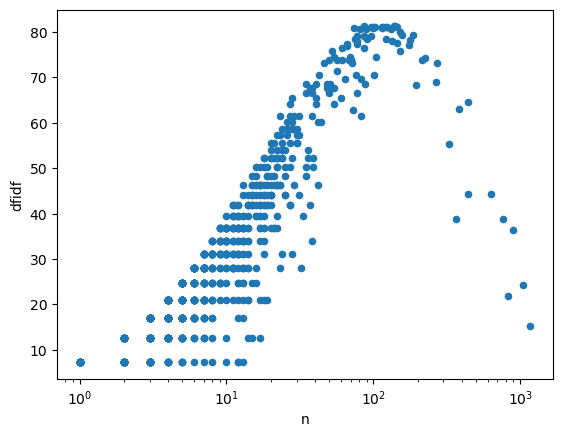

In [31]:
VOCAB.plot.scatter('n', 'dfidf', logx=True);

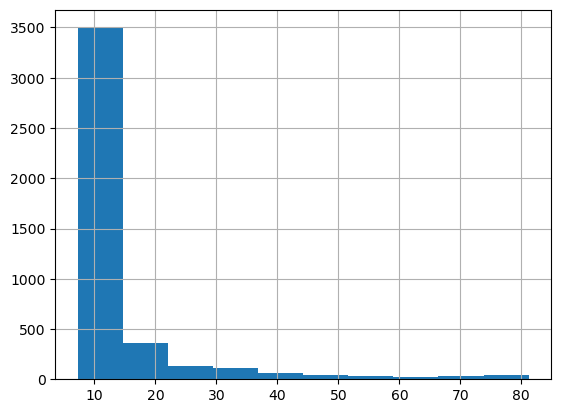

In [32]:
VOCAB.dfidf.hist();

In [33]:
VOCAB['dfidf_group'] = VOCAB.dfidf.round().astype(int)

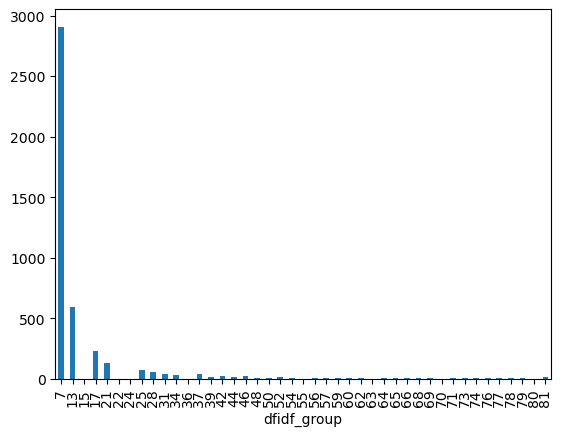

In [34]:
VOCAB.groupby('dfidf_group').count().n.sort_index().plot.bar();

In [35]:
VOCAB[VOCAB.dfidf_group >= 8]

,n,p,df,dfidf,dfidf_group
term_str,,,,,
a,38,0.001447,26,66.480651,66
a',6,0.000228,6,28.034552,28
ab'aj,26,0.000990,20,58.709195,59
ab'ix,5,0.000190,3,17.017276,17
ab'ixik,4,0.000152,4,21.029551,21
...,...,...,...,...,...
yakalik,3,0.000114,3,17.017276,17
yaki,7,0.000267,5,24.677299,25
yakolatam,2,0.000076,2,12.514776,13


In [36]:
VOCAB[VOCAB.dfidf_group < 8]

,n,p,df,dfidf,dfidf_group
term_str,,,,,
a'on,1,0.000038,1,7.257388,7
ab'ajil,1,0.000038,1,7.257388,7
ab'anel,1,0.000038,1,7.257388,7
ab'anoj,1,0.000038,1,7.257388,7
ab'i',2,0.000076,1,7.257388,7
...,...,...,...,...,...
yolkwat,1,0.000038,1,7.257388,7
yoq'b'al,1,0.000038,1,7.257388,7
yoq'otajinaq,1,0.000038,1,7.257388,7


In [37]:
# Chunk
# n_chunks = 25

In [38]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, message=".*swapaxes.*")
TOKEN['chunk_id'] = np.concatenate([
    np.full(len(chunk), i) 
    for i, chunk 
    in enumerate(np.array_split(TOKEN, n_chunks))
])
CHUNK = TOKEN.groupby('chunk_id').term_str.apply(lambda x: ' '.join(x)).to_frame('chunk_str')
CHUNK['n_tokens'] = CHUNK.chunk_str.str.split().str.len()

In [39]:
CHUNK

,chunk_str,n_tokens
chunk_id,,
0,popol wuj ojer taq tzij xb'an pa tinamit k'ich...,526
1,raxakaqulja xchutzinik qatz'aq qab'it xecha' k...,526
2,chik ri kitz'aq kib'it xecha' chi k'ut jupacha...,526
3,nimachikop xk'ut kiwach rumal che' ab'aj xch'a...,526
4,kukakab'ej keje k'ut chub'ano ronojel winaq ma...,526
5,ati't kachb'ilan kib' a pa kixpe wi qamam xcha...,526
6,k'ut jun nimajul najt xqajik ta xkitaq k'ut ri...,526
7,xb'alanq'e are k'ut xkikoj ri uwach ek' ri maq...,526
8,chib'ulij ta xk'ulutaj kumal ri k'ajolab' a pa...,526


In [40]:
TOKEN.to_csv("ajtzibab-TOKEN.csv", index=True)
VOCAB.to_csv("ajtzibab-VOCAB.csv", index=True)
CHUNK.to_csv("ajtzibab-CHUNK.csv", index=True)